# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')

chromatin_model1 = ChromatinModel(config1)

todo: Loading testing config from replication deconvolution


In [14]:
mnase_span = (770900, 771900)
chromatin_model1.load_mnase_span(chrom=16, mnase_span=mnase_span)

Already loaded chromosome reads for 16. Using cache.
Applying a normalization for length distribution


In [15]:
from src.chromatin_deconvolution_solver import example_N_frep_b

padding_type = 'both'
N, f_rep, b = example_N_frep_b(config1)


In [16]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep,
    padding_type='both', subsample=5)

Subsampling to top 5 sites
Indices with the highest max value:  [ 602 1104 1707 1707 1707 1707 1707 1707 1707 2109 1608 1707  915 1841
 1841 1707]


In [24]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.00001,
    gamma_max=0.0001)

	Base error (γ=0):	rn: 0.043137	sn: 105.085570
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0452935
			Absolute (e0 + 0.04): 0.0831367
			Chosen: 0.045293
		Right:
			Relative (1.40 * e0): 0.0603913
			Absolute (e0 + 0.32): 0.363137
			Chosen: 0.363137
	Searching for left boundary gamma...
		γ: 5.5e-05	rn: 0.0479	sn: 0.7499
		γ: 3.25e-05	rn: 0.0469	sn: 0.9200
		γ: 2.125e-05	rn: 0.0466	sn: 1.0069
		γ: 1.5625e-05	rn: 0.0459	sn: 1.1669
		γ: 1.28125e-05	rn: 0.0456	sn: 1.2792
		γ: 1.14062e-05	rn: 0.0455	sn: 1.3229
		γ: 1.07031e-05	rn: 0.0455	sn: 1.3595
	Left boundary gamma found: 1.03516e-05
	Searching for right boundary gamma...
		γ: 5.51758e-05	rn: 0.0479	sn: 0.7494
		γ: 7.75879e-05	rn: 0.0486	sn: 0.6824
		γ: 8.87939e-05	rn: 0.0490	sn: 0.6441
		γ: 9.4397e-05	rn: 0.0493	sn: 0.6306
		γ: 9.71985e-05	rn: 0.0493	sn: 0.6255
		γ: 9.85992e-05	rn: 0.0494	sn: 0.6226
		γ: 9.92996e-05	rn: 0.0494	sn: 0.6213
	Right boundary gamma found: 9.96498e-05
Finding elbow in the curve, selecting 20 bins

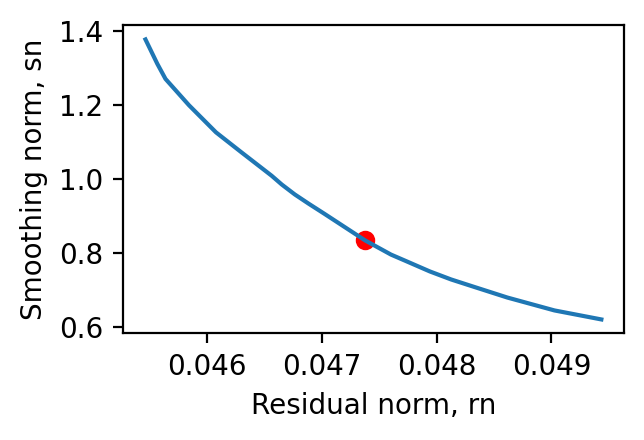

In [25]:
chrom_find_gamma.find_optimal_gamma()

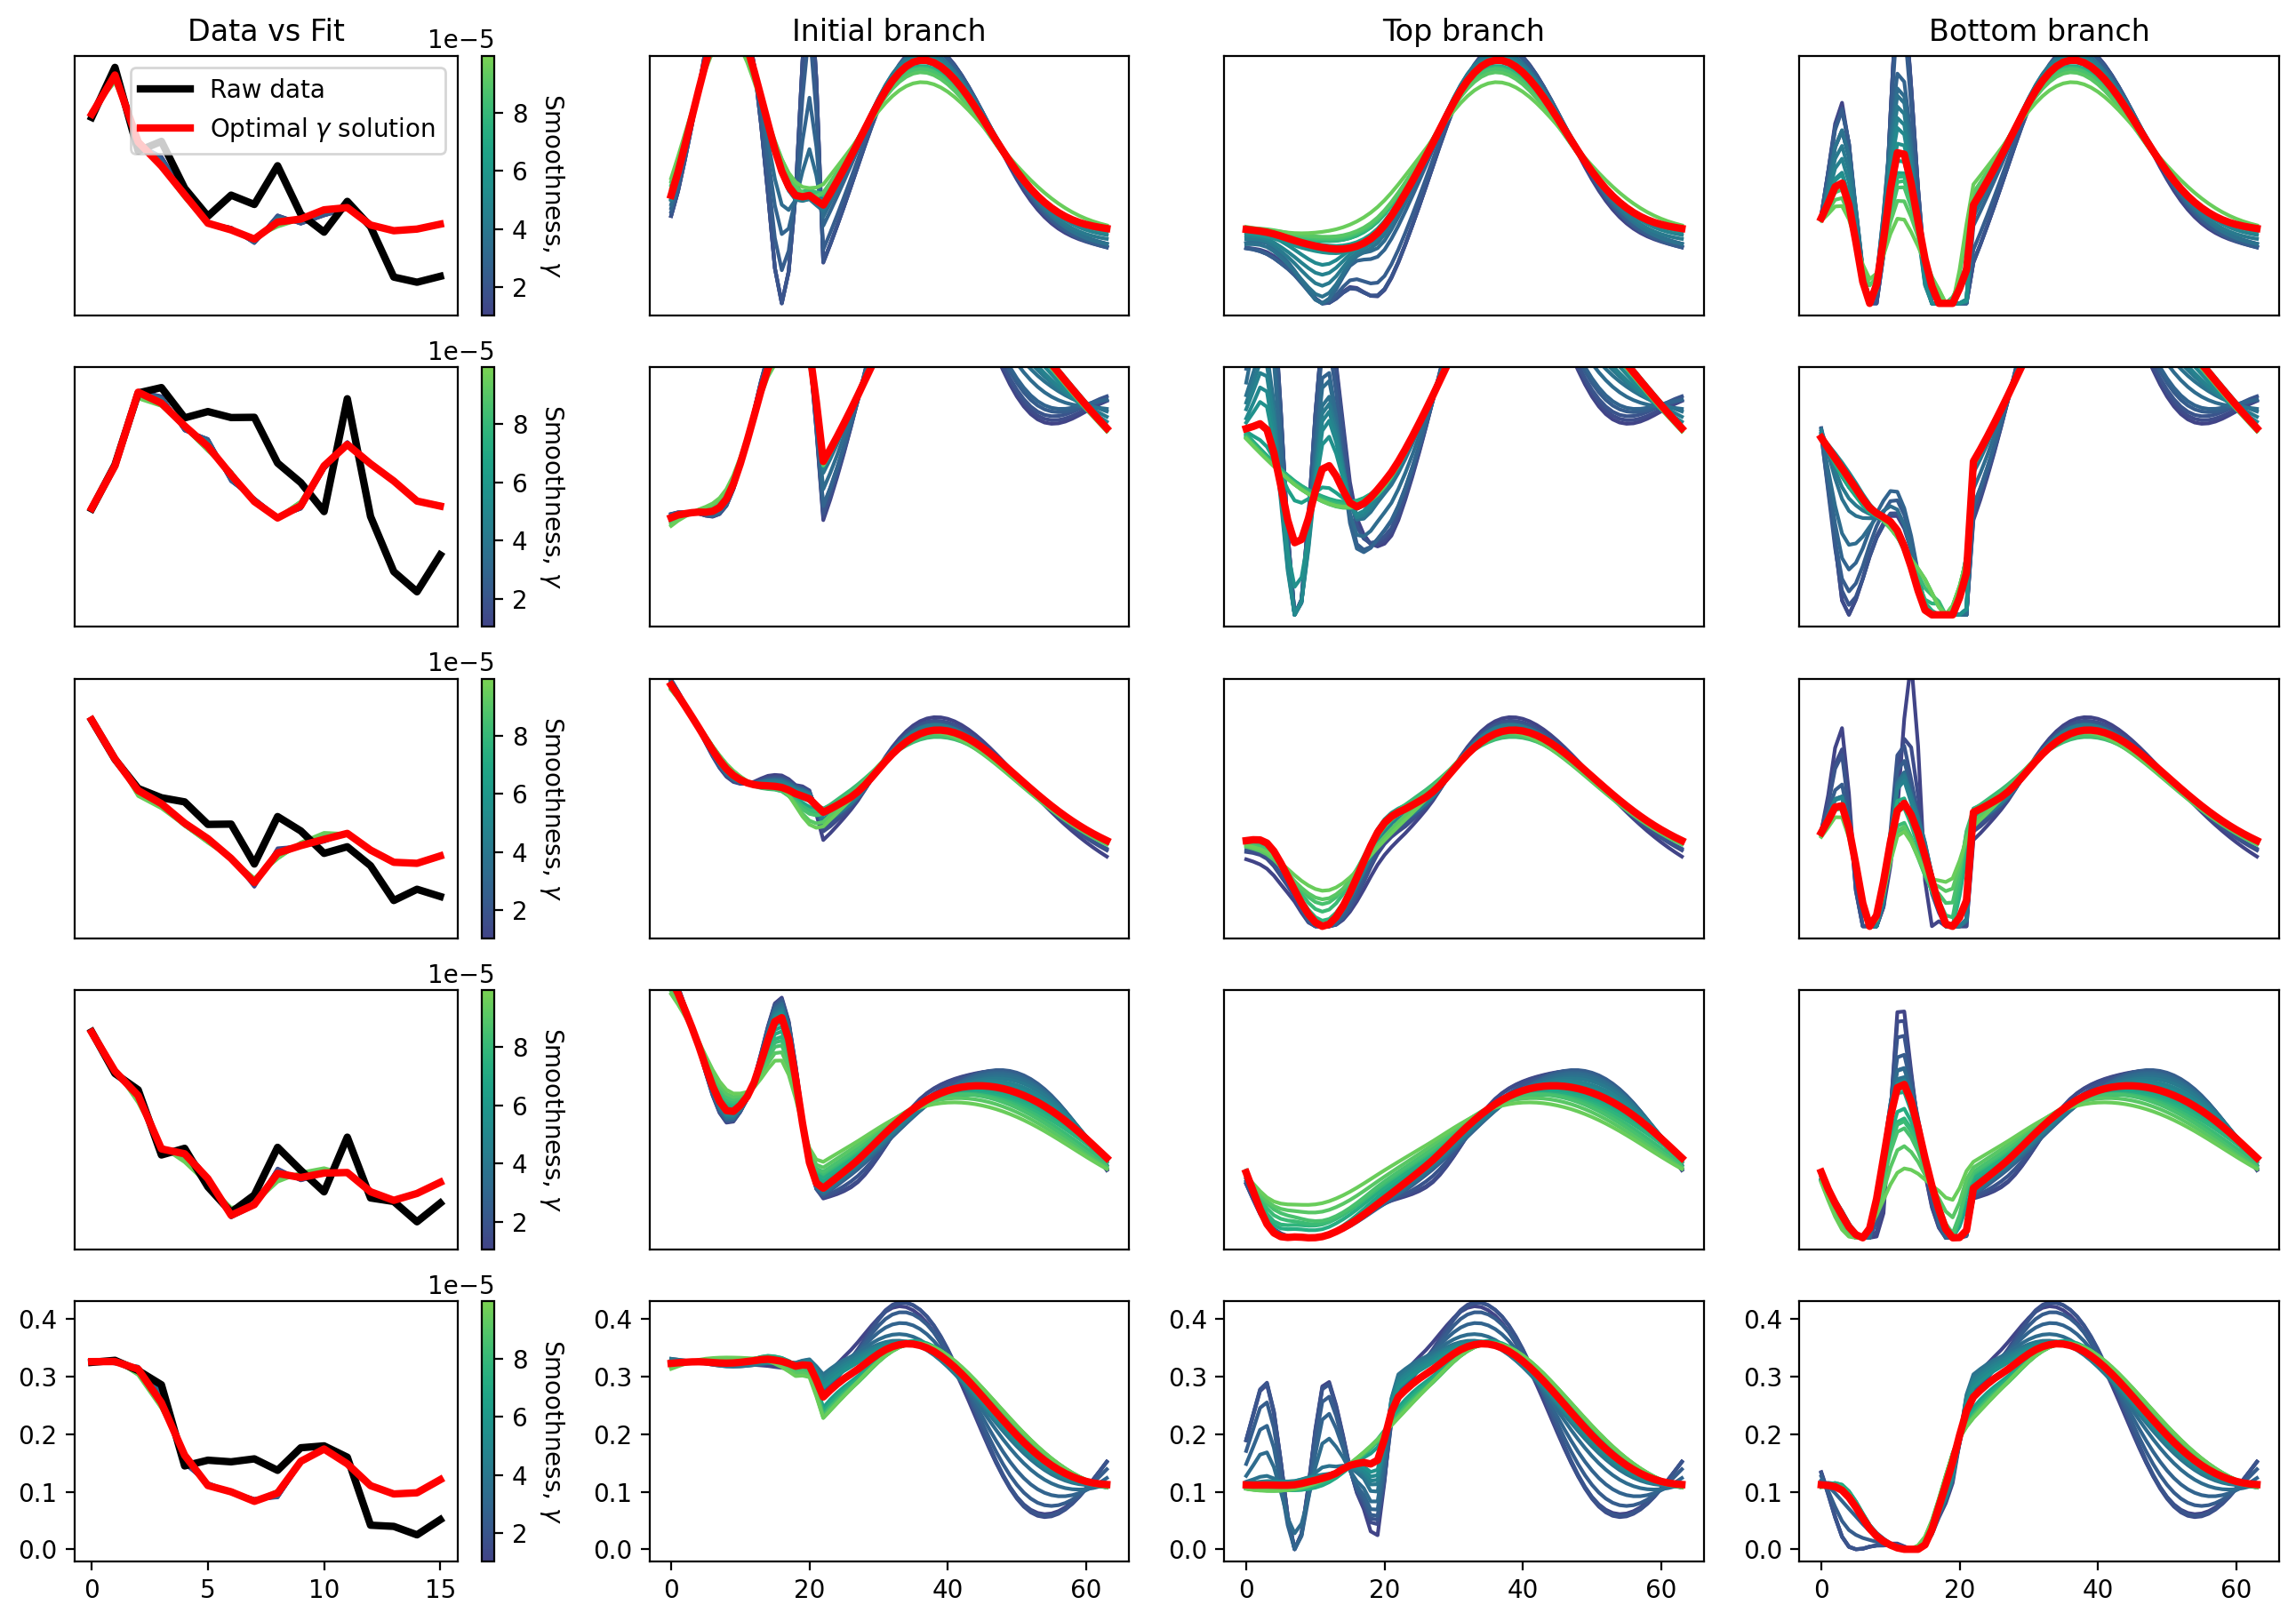

In [26]:
gamma_predicted_Gs_test = chrom_find_gamma.plot_gamma_sweep()

In [33]:
chromatin_solver_full = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver_full.deconvolve_G_iteratively(
   gamma=2e-4) # Testing hardcoded gamma for sensitivity analysis
#chrom_find_gamma.gamma_optimizer.optimal_gamma)

0/2600 - 00:00:00.001
500/2600 - 00:00:04.827
1000/2600 - 00:00:42.038
1500/2600 - 00:01:24.144
2000/2600 - 00:02:16.704
2500/2600 - 00:03:10.522


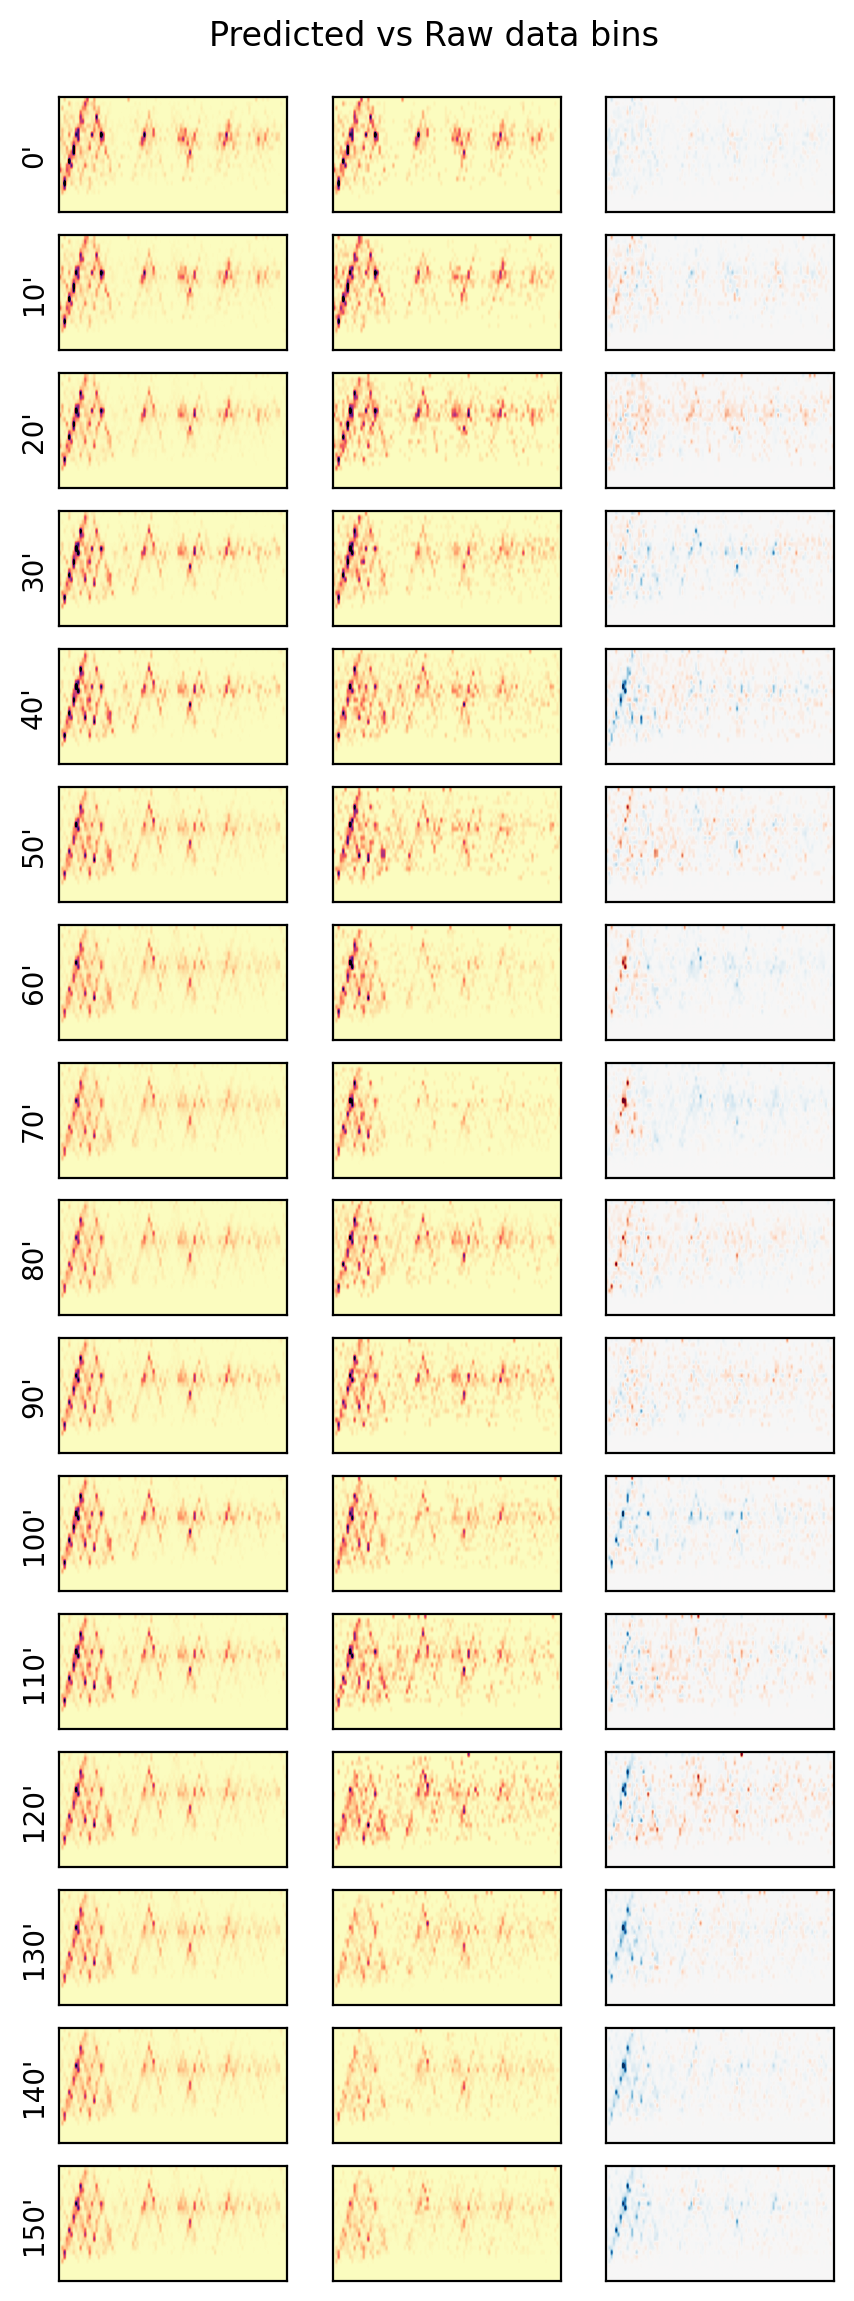

In [34]:
from src.chromatin_model import plot_prediction

plot_prediction(config1, N, full_deconvolved_F, f_rep, chromatin_model1.G, b)


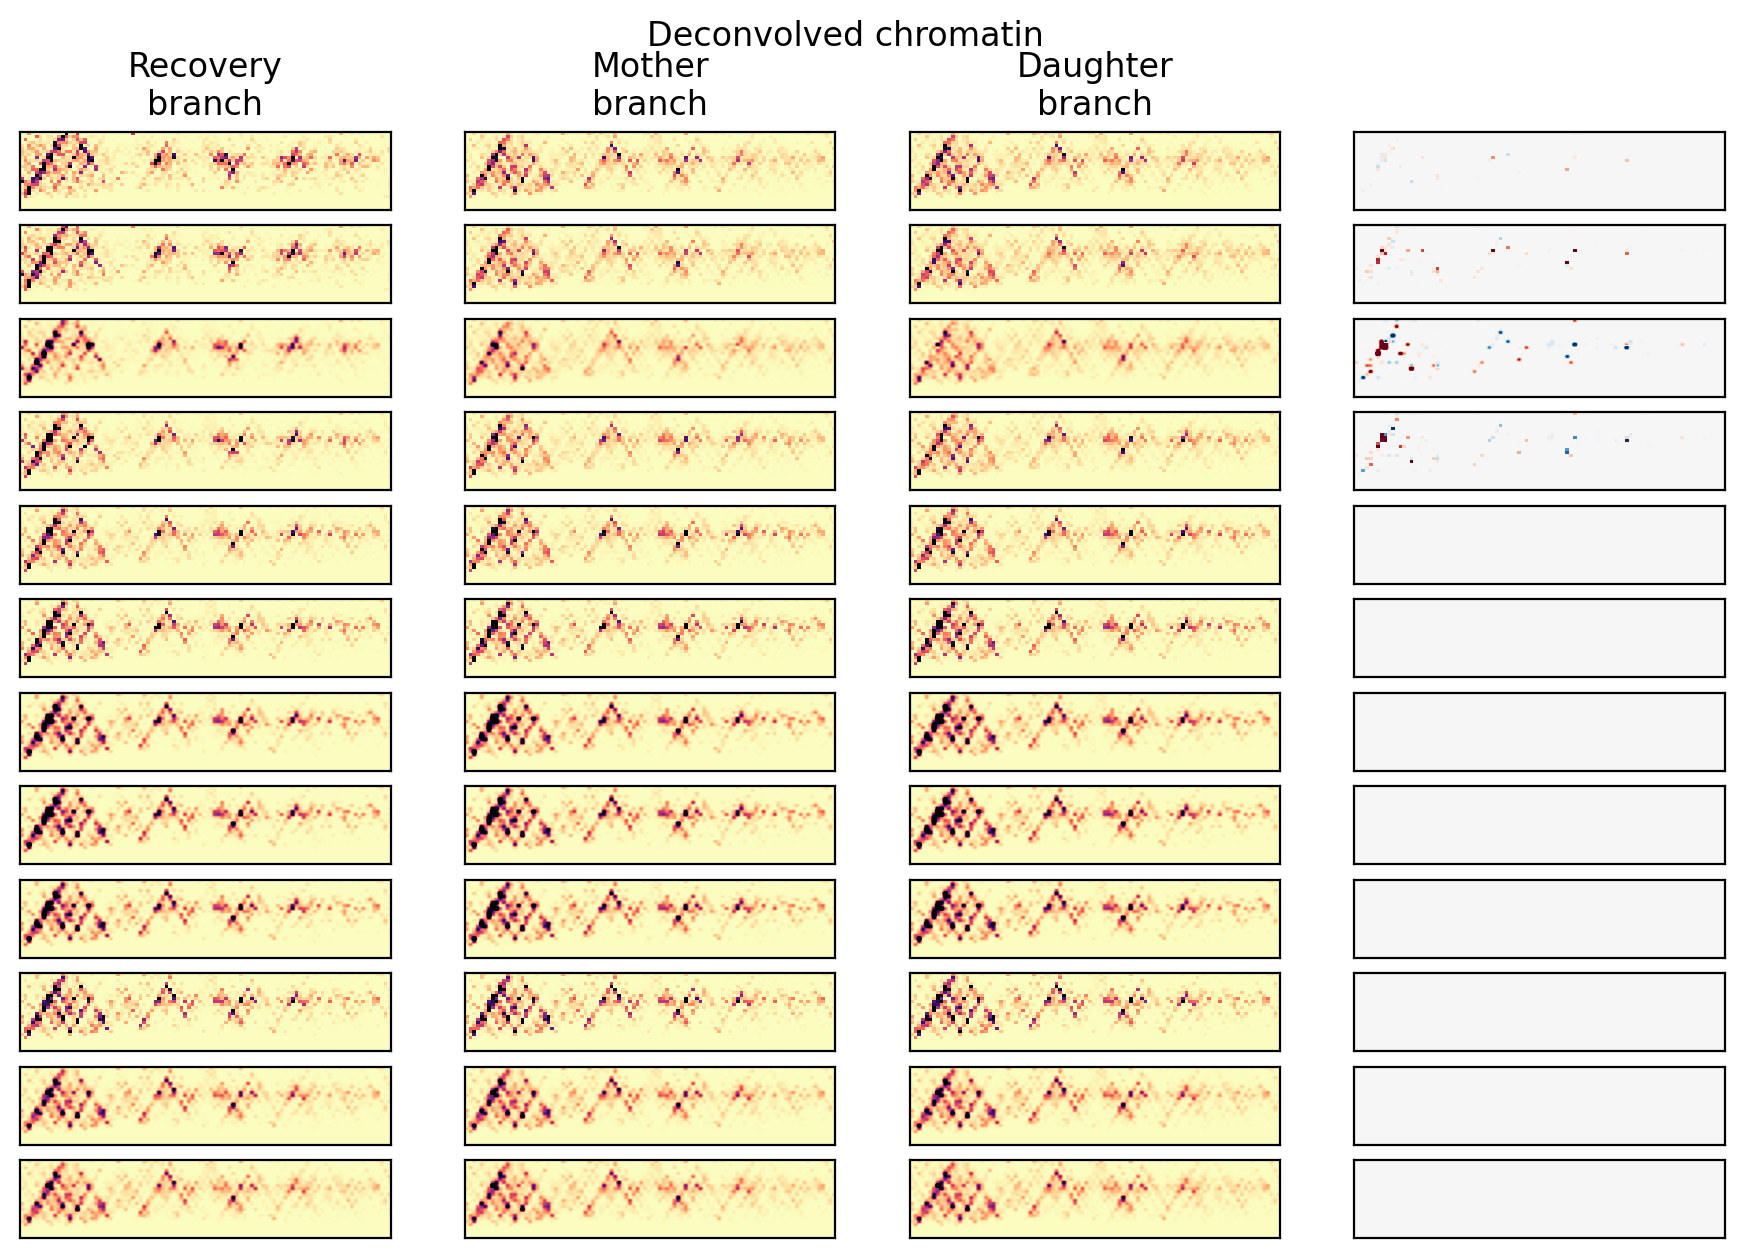

In [35]:
from src.chromatin_deconvolution_solver import plot_branches

plot_branches(config1, full_deconvolved_F)
